In [55]:
import numpy as np
from mlcolvar.io import load_dataframe
from mlcolvar.utils.fes import compute_fes
from mlcolvar.utils.plot import paletteFessa
import matplotlib.pyplot as plt

In [71]:
# Load COLVAR file containing collective variables 
colvar = load_dataframe("700K_explore/COLVAR")
colvar.head()

FileNotFoundError: [Errno 2] No such file or directory: '700K_explore/COLVAR'

<Axes: xlabel='time'>

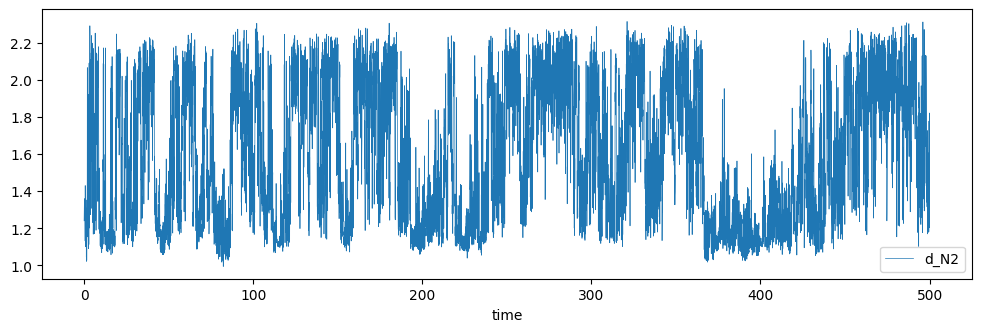

In [64]:
colvar.plot(x="time",y="d_N2", linewidth=0.5, figsize=(12,3.5))

<Axes: xlabel='d_N2', ylabel='c_N_Fe'>

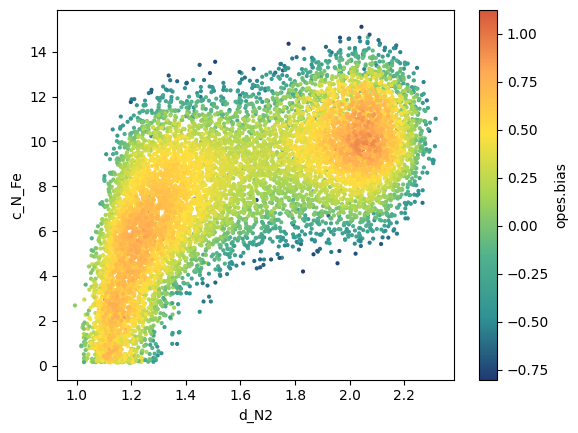

In [68]:
colvar.plot.scatter(x="d_N2",y="c_N_Fe",c="opes.bias",cmap='fessa', s=4)

<Axes: xlabel='time'>

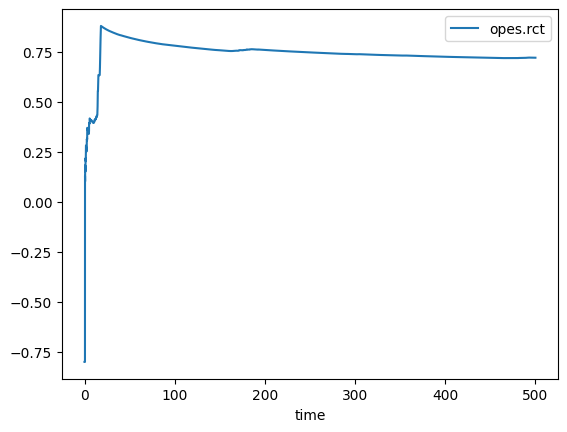

In [69]:
colvar.plot(x="time",y="opes.rct")

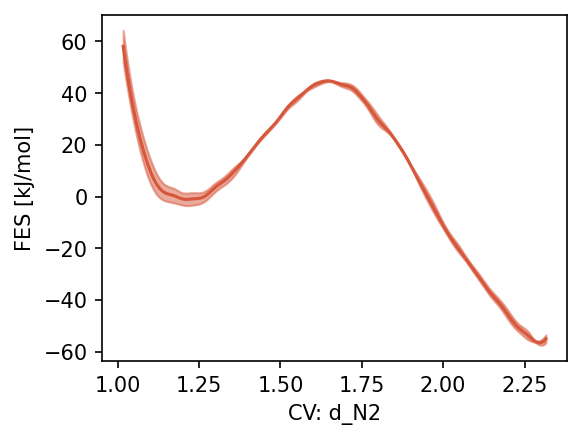

In [76]:
# Discard initial part of the trajectory for equilibration
colvar2 = colvar[2000:]

cv_name = 'd_N2'

cv1 = colvar2[cv_name].values

# kBT 
temperature = 700
kb = 0.0083144621 / 96      # Boltzmann constant ev/K
kbt = kb * temperature

# Calculate weight: reweight all field *.bias in the COLVAR
bias = colvar2.filter(regex='.bias').sum(axis=1).values
weights = np.exp( bias / kbt )

fes_params = {
    'blocks': 3,            # Number of blocks for error analysis
    'fes_to_zero' : 25,
    'bandwidth': 0.015,      # Kernel bandwidth (sigma) for density estimation. if 'range', the bandwidth is expressed as ratio of the range of values (e.g. here it is 1% of it)
    'scale_by': 'range',    # Method to scale the bandwidth
    'temp' : temperature,   # temperature for proper energy scaling (alternative to kbt)
    'units': 'kJ/mol',  # units of the free energy
    'weights': weights,     # Statistical weights from the bias
}

fig, ax = plt.subplots(figsize=(4,3),dpi=150)
fes1D, grid1D, bounds1D, error1D = compute_fes(
    cv1,
    plot=True,
    ax = ax,
    **fes_params
)
ax.set_xlabel(f'CV: {cv_name}')
plt.show()